# Inference and Policy Demo

A small runnable demo of one belief update and one policy comparison.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\49160\Adaptive-Onboarding")
sys.path.append(str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)


Project root: C:\Users\49160\Adaptive-Onboarding


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from src.belief import BeliefState
from src.grm import category_probabilities
from src.item_bank import Item
from src.policies import make_sensitive_level_stay_prob, score_bank, select_next_item
from src.updates import (
    projected_mean_variance,
    one_step_posterior_coefficients,
    update_belief,
    damped_update_belief,
)
from src.plots import apply_notebook_style

apply_notebook_style()


## Setup

In [3]:
belief0 = BeliefState(
    mu=np.array([0.4, -0.3]),
    Sigma=np.array([[1.2, 0.25], [0.25, 0.9]]),
)

item_focus = Item(
    item_id="q_focus",
    a=np.array([1.0, -0.6]),
    thresholds=np.array([-0.7, 0.3]),
    is_sensitive=True,
    sensitivity_level=0.4,
)

item_bank = [
    item_focus,
    Item("q_sleep", np.array([0.9, 0.1]), np.array([-0.5, 0.4]), is_sensitive=True, sensitivity_level=0.1),
    Item("q_support", np.array([0.2, -1.1]), np.array([-0.3, 0.6]), is_sensitive=True, sensitivity_level=0.2),
    Item("q_risk", np.array([1.1, -0.2]), np.array([-1.0, 0.0]), is_sensitive=True, sensitivity_level=0.9),
]

observed_response = 1
stay_prob_fn = make_sensitive_level_stay_prob(gamma0=0.65, gamma_step=0.10)

## One Belief Update

In [4]:
prior_probs = category_probabilities(belief0, item_focus)
m, v, p_r = one_step_posterior_coefficients(belief0, item_focus, observed_response)

belief_undamped = update_belief(belief0, item_focus, observed_response)
belief_damped = damped_update_belief(belief0, item_focus, observed_response)

_, var_prior = projected_mean_variance(belief0, item_focus)
_, var_undamped = projected_mean_variance(belief_undamped, item_focus)
_, var_damped = projected_mean_variance(belief_damped, item_focus)

print("Prior category probabilities:")
for r, p in enumerate(prior_probs):
    marker = " <- observed" if r == observed_response else ""
    print(f"  r={r}: {p:.4f}{marker}")

print(f"\nm = {m:+.4f}")
print(f"v = {v:.4f}")
print(f"p_r = {p_r:.4f}")
print("\nProjected variance a^T Sigma a:")
print(f"  before update         : {var_prior:.4f}")
print(f"  after undamped update : {var_undamped:.4f}")
print(f"  after damped update   : {var_damped:.4f}")

Prior category probabilities:
  r=0: 0.1954
  r=1: 0.2302 <- observed
  r=2: 0.5745

m = -0.3737
v = 0.4698
p_r = 0.2302

Projected variance a^T Sigma a:
  before update         : 1.2240
  after undamped update : 0.5751
  after damped update   : 0.9716


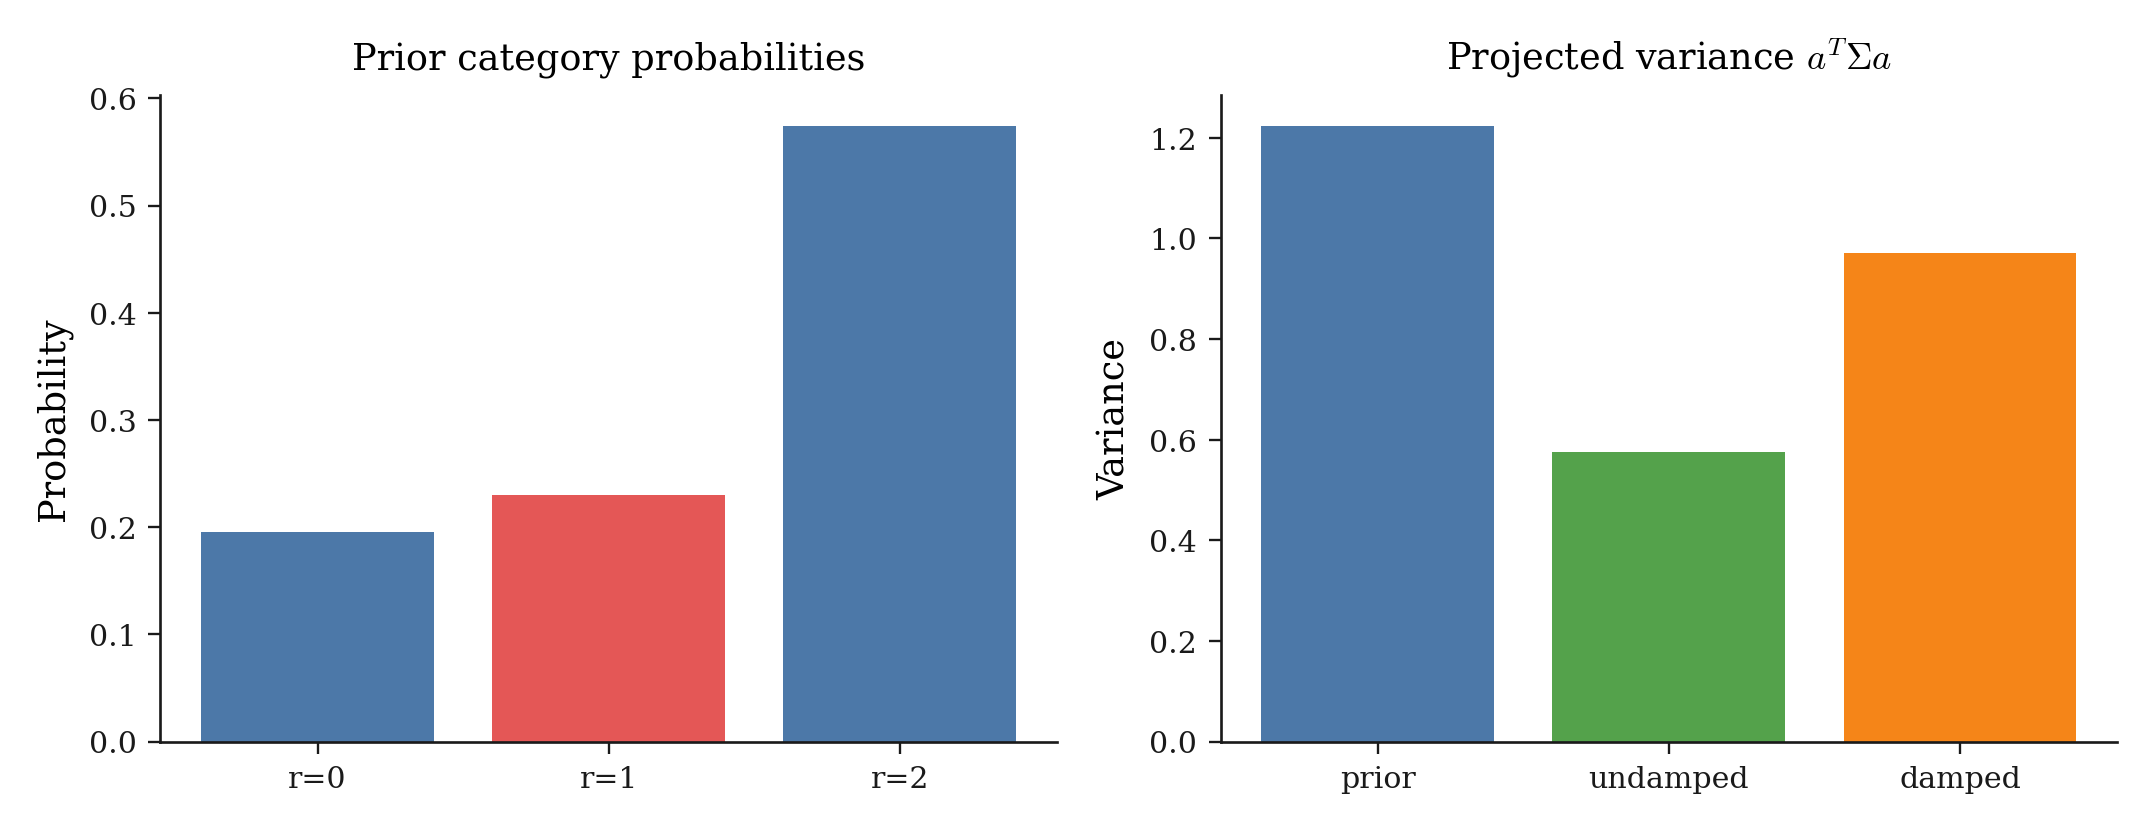

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

bar_colors = ["#4C78A8"] * len(prior_probs)
bar_colors[observed_response] = "#E45756"
axes[0].bar(range(len(prior_probs)), prior_probs, color=bar_colors)
axes[0].set_xticks(range(len(prior_probs)))
axes[0].set_xticklabels([f"r={r}" for r in range(len(prior_probs))])
axes[0].set_title("Prior category probabilities")
axes[0].set_ylabel("Probability")

variance_labels = ["prior", "undamped", "damped"]
variance_values = [var_prior, var_undamped, var_damped]
axes[1].bar(variance_labels, variance_values, color=["#4C78A8", "#54A24B", "#F58518"])
axes[1].set_title(r"Projected variance $a^T\Sigma a$")
axes[1].set_ylabel("Variance")

plt.tight_layout()
plt.show()

## Policy Comparison

In [6]:
step = 0

scored_unweighted = score_bank(
    belief=belief0,
    item_bank=item_bank,
    step=step,
    weighted=False,
    stay_prob_fn=stay_prob_fn,
)
scored_weighted = score_bank(
    belief=belief0,
    item_bank=item_bank,
    step=step,
    weighted=True,
    stay_prob_fn=stay_prob_fn,
)

print("Unweighted ranking:")
for rank, row in enumerate(scored_unweighted, start=1):
    print(f"  {rank}. {row.item.item_id:10s} score={row.score:.4f} var={row.projected_variance:.4f} p_stay={row.stay_prob:.3f}")

print("\nWeighted ranking:")
for rank, row in enumerate(scored_weighted, start=1):
    print(f"  {rank}. {row.item.item_id:10s} score={row.score:.4f} var={row.projected_variance:.4f} p_stay={row.stay_prob:.3f}")

selected_unweighted = select_next_item(
    belief=belief0,
    item_bank=item_bank,
    step=step,
    strategy="surrogate_unweighted",
    stay_prob_fn=stay_prob_fn,
)
selected_weighted = select_next_item(
    belief=belief0,
    item_bank=item_bank,
    step=step,
    strategy="surrogate_weighted",
    stay_prob_fn=stay_prob_fn,
)

print("\nSelected next item:")
print("  unweighted:", selected_unweighted.item_id)
print("  weighted  :", selected_weighted.item_id)

Unweighted ranking:
  1. q_risk     score=0.8663 var=1.3780 p_stay=1.000
  2. q_focus    score=0.7993 var=1.2240 p_stay=1.000
  3. q_support  score=0.7066 var=1.0270 p_stay=1.000
  4. q_sleep    score=0.7061 var=1.0260 p_stay=1.000

Weighted ranking:
  1. q_sleep    score=0.6726 var=1.0260 p_stay=0.935
  2. q_focus    score=0.6449 var=1.2240 p_stay=0.740
  3. q_support  score=0.6384 var=1.0270 p_stay=0.870
  4. q_risk     score=0.4523 var=1.3780 p_stay=0.415

Selected next item:
  unweighted: q_risk
  weighted  : q_sleep


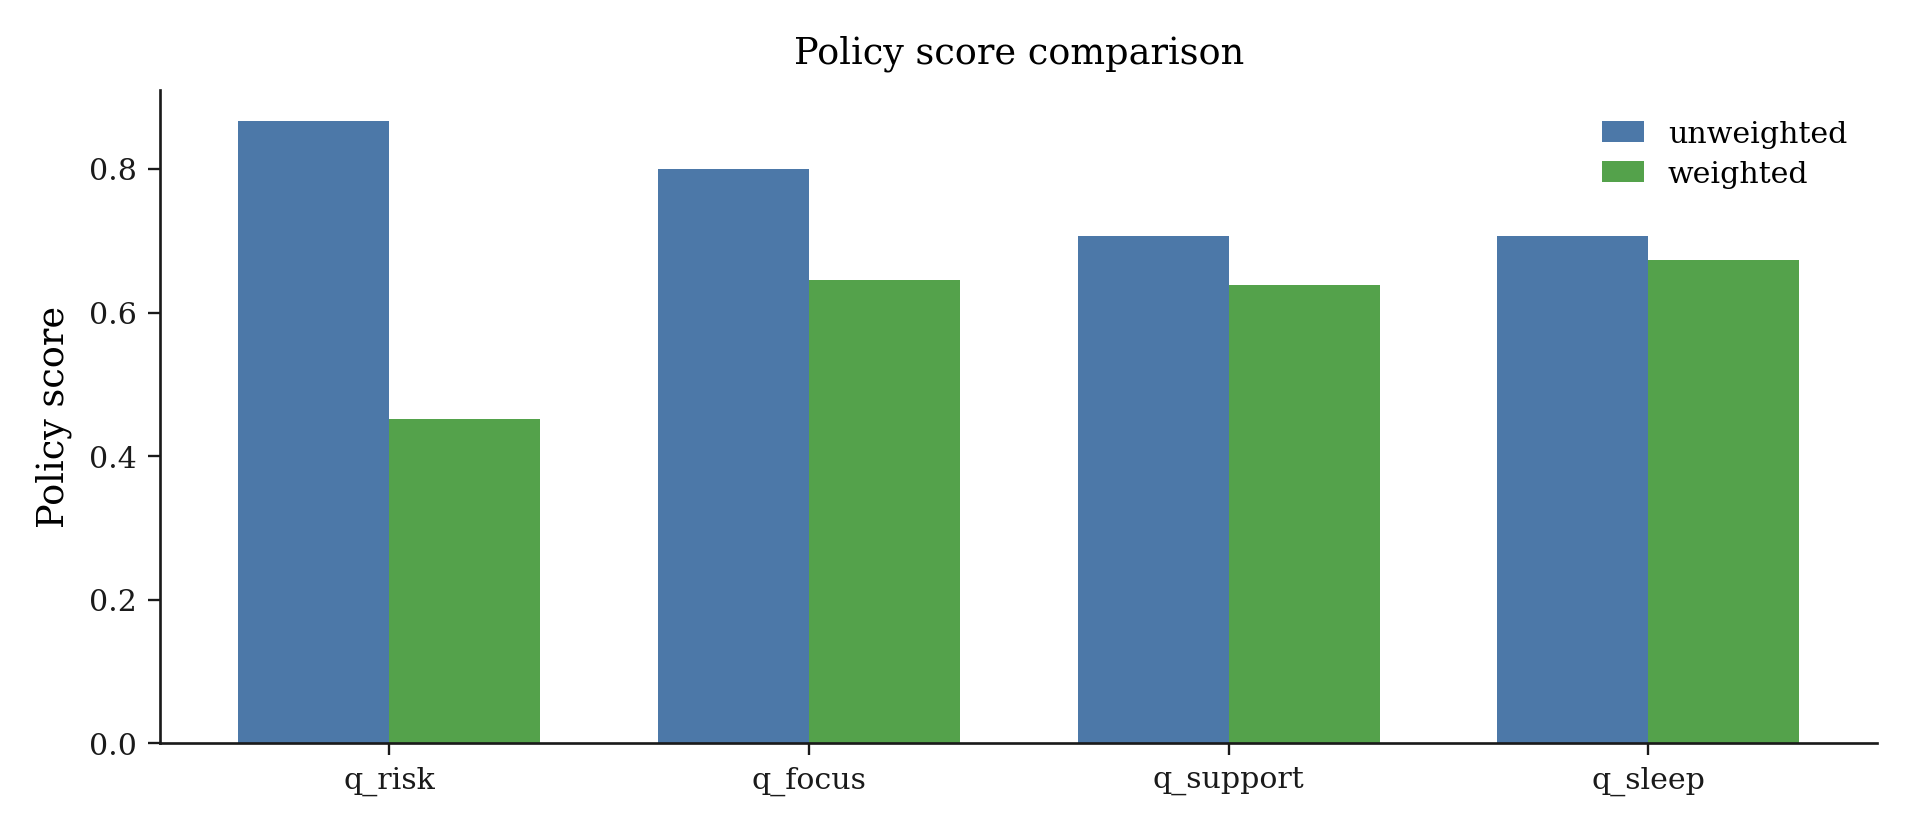

In [7]:
item_ids = [row.item.item_id for row in scored_unweighted]
unweighted_scores = [row.score for row in scored_unweighted]
weighted_by_id = {row.item.item_id: row.score for row in scored_weighted}
weighted_scores = [weighted_by_id[item_id] for item_id in item_ids]

x = np.arange(len(item_ids))
width = 0.36

plt.figure(figsize=(8, 3.5))
plt.bar(x - width / 2, unweighted_scores, width=width, label="unweighted", color="#4C78A8")
plt.bar(x + width / 2, weighted_scores, width=width, label="weighted", color="#54A24B")
plt.xticks(x, item_ids)
plt.ylabel("Policy score")
plt.title("Policy score comparison")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()